# Activation

In [1]:
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
torch.manual_seed(2)

In [3]:
z = torch.arange(-10, 10, 0.1,).view(-1, 1)
z

tensor([[-1.0000e+01],
        [-9.9000e+00],
        [-9.8000e+00],
        [-9.7000e+00],
        [-9.6000e+00],
        [-9.5000e+00],
        [-9.4000e+00],
        [-9.3000e+00],
        [-9.2000e+00],
        [-9.1000e+00],
        [-9.0000e+00],
        [-8.9000e+00],
        [-8.8000e+00],
        [-8.7000e+00],
        [-8.6000e+00],
        [-8.5000e+00],
        [-8.4000e+00],
        [-8.3000e+00],
        [-8.2000e+00],
        [-8.1000e+00],
        [-8.0000e+00],
        [-7.9000e+00],
        [-7.8000e+00],
        [-7.7000e+00],
        [-7.6000e+00],
        [-7.5000e+00],
        [-7.4000e+00],
        [-7.3000e+00],
        [-7.2000e+00],
        [-7.1000e+00],
        [-7.0000e+00],
        [-6.9000e+00],
        [-6.8000e+00],
        [-6.7000e+00],
        [-6.6000e+00],
        [-6.5000e+00],
        [-6.4000e+00],
        [-6.3000e+00],
        [-6.2000e+00],
        [-6.1000e+00],
        [-6.0000e+00],
        [-5.9000e+00],
        [-5.8000e+00],
        [-5

##  Sigmoid

In [5]:
sig = nn.Sigmoid()
y_hat = sig(z)
y_hat

tensor([[4.5398e-05],
        [5.0172e-05],
        [5.5449e-05],
        [6.1280e-05],
        [6.7724e-05],
        [7.4846e-05],
        [8.2717e-05],
        [9.1416e-05],
        [1.0103e-04],
        [1.1165e-04],
        [1.2339e-04],
        [1.3637e-04],
        [1.5071e-04],
        [1.6656e-04],
        [1.8407e-04],
        [2.0343e-04],
        [2.2482e-04],
        [2.4846e-04],
        [2.7458e-04],
        [3.0345e-04],
        [3.3535e-04],
        [3.7061e-04],
        [4.0957e-04],
        [4.5262e-04],
        [5.0020e-04],
        [5.5278e-04],
        [6.1088e-04],
        [6.7508e-04],
        [7.4603e-04],
        [8.2442e-04],
        [9.1105e-04],
        [1.0068e-03],
        [1.1125e-03],
        [1.2294e-03],
        [1.3585e-03],
        [1.5012e-03],
        [1.6588e-03],
        [1.8329e-03],
        [2.0253e-03],
        [2.2378e-03],
        [2.4726e-03],
        [2.7320e-03],
        [3.0184e-03],
        [3.3348e-03],
        [3.6842e-03],
        [4

### Torch.detach() 核心功能：断开梯度连接

当你对一个 Tensor 调用 .detach() 时，它会返回一个新的 Tensor，这个新 Tensor：

共享底层数据：它和原始 Tensor 指向同一块内存，不会增加内存开销。

脱离计算图：它的 requires_grad 属性会被设为 False。

没有 grad_fn：这意味着在执行 loss.backward() 时，梯度流传到这个 Tensor 就会彻底停止，不会再向前面的层回传。

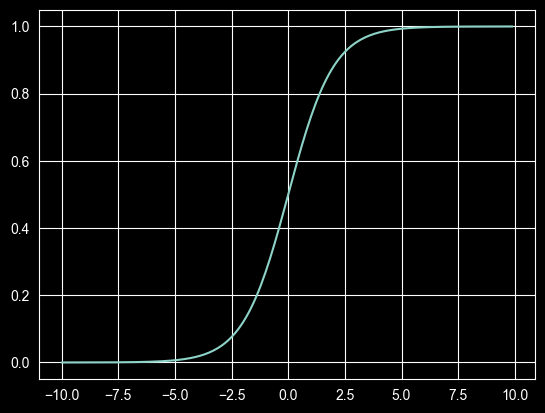

In [6]:
plt.plot(z.detach().numpy(), y_hat.detach().numpy())

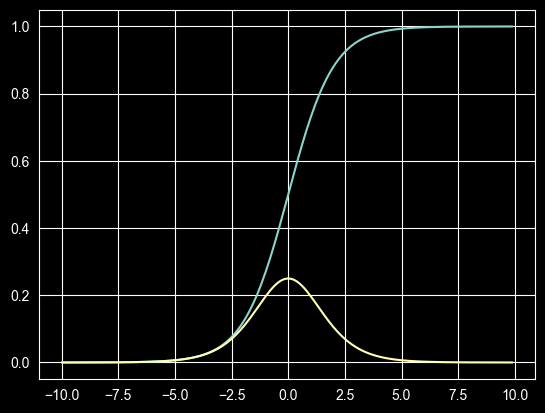

In [19]:
z.requires_grad_(True)
yhat = torch.sigmoid(z)
plt.plot(z.detach().numpy(), yhat.detach().numpy(),label='sigmoid')

yhat.backward(torch.ones_like(z))
sig_grad = z.grad.clone()
z.grad.zero_()
plt.plot(z.detach().numpy(), sig_grad.detach().numpy(), label='Derivative')

##  Tanh

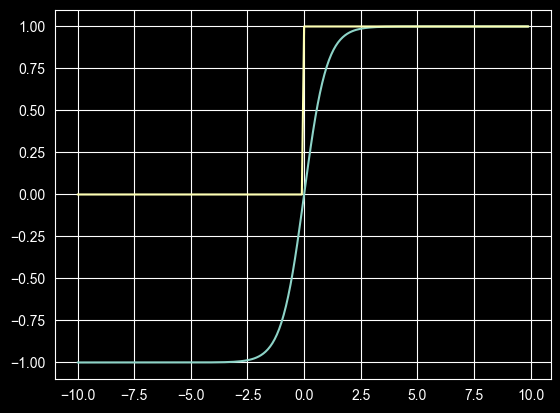

In [18]:
z.requires_grad_(True)

tanh = nn.Tanh()
yhat = tanh(z)
plt.plot(z.detach().numpy(), yhat.detach().numpy(), label='tanh')
relu = nn.ReLU()
yhat = relu(z)

# 求导
yhat.backward(torch.ones_like(z))
tanh_grad = z.grad.clone()
z.grad.zero_()
plt.plot(z.detach().numpy(), tanh_grad.detach().numpy(), label='Derivative')
relu_grad = z.grad.clone()

## Relu

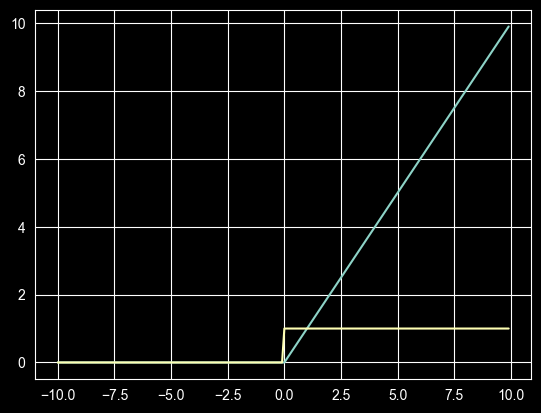

In [15]:
relu = nn.ReLU()
yhat = relu(z)

## 求导
z.requires_grad_(True)
yhat.backward(torch.ones_like(z))
relu_grad = z.grad.clone()
z.grad.zero_()

plt.plot(z.detach().numpy(), yhat.detach().numpy(), label='ReLU')
plt.plot(z.detach().numpy(), relu_grad.detach().numpy(), label='Derivative')

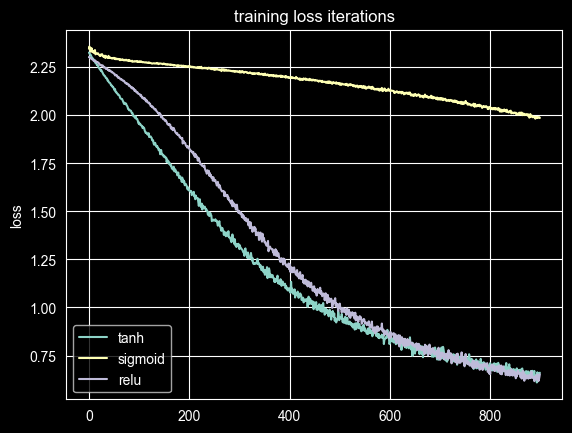

In [20]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

import matplotlib.pylab as plt
import numpy as np

class Net(nn.Module):

    # Constructor
    def __init__(self, D_in, H, D_out):
        super(Net, self).__init__()
        self.linear1 = nn.Linear(D_in, H)
        self.linear2 = nn.Linear(H, D_out)

    # Prediction
    def forward(self, x):
        x = torch.sigmoid(self.linear1(x))
        x = self.linear2(x)
        return x


class NetTanh(nn.Module):

    # Constructor
    def __init__(self, D_in, H, D_out):
        super(NetTanh, self).__init__()
        self.linear1 = nn.Linear(D_in, H)
        self.linear2 = nn.Linear(H, D_out)

    # Prediction
    def forward(self, x):
        x = torch.tanh(self.linear1(x))
        x = self.linear2(x)
        return x
class NetRelu(nn.Module):

    # Constructor
    def __init__(self, D_in, H, D_out):
        super(NetRelu, self).__init__()
        self.linear1 = nn.Linear(D_in, H)
        self.linear2 = nn.Linear(H, D_out)

    # Prediction
    def forward(self, x):
        x = torch.relu(self.linear1(x))
        x = self.linear2(x)
        return x

train_dataset = dsets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())


validation_dataset = dsets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

def train(model, criterion, train_loader, validation_loader, optimizer, epochs = 100):
    i = 0
    useful_stuff = {'training_loss':[], 'validation_accuracy':[]}

    for epoch in range(epochs):
        for i, (x, y) in enumerate(train_loader):
            optimizer.zero_grad()
            z = model(x.view(-1, 28 * 28))
            loss = criterion(z, y)
            loss.backward()
            optimizer.step()
            useful_stuff['training_loss'].append(loss.item())

        correct = 0
        for x, y in validation_loader:
            z = model(x.view(-1, 28 * 28))
            _, label=torch.max(z, 1)
            correct += (label == y).sum().item()
        accuracy = 100 * (correct / len(validation_dataset))
        useful_stuff['validation_accuracy'].append(accuracy)

    return useful_stuff
criterion = nn.CrossEntropyLoss()

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=2000, shuffle=True)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000, shuffle=False)

criterion = nn.CrossEntropyLoss()


input_dim = 28 * 28
hidden_dim = 100
output_dim = 10

model = Net(input_dim, hidden_dim, output_dim)

# Train a model with sigmoid function

learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
training_results = train(model, criterion, train_loader, validation_loader, optimizer, epochs=30)

# Train a model with Tanh function

model_Tanh = NetTanh(input_dim, hidden_dim, output_dim)
optimizer = torch.optim.SGD(model_Tanh.parameters(), lr=learning_rate)
training_results_tanch = train(model_Tanh, criterion, train_loader, validation_loader, optimizer, epochs=30)
# Train a model with Relu function

modelRelu = NetRelu(input_dim, hidden_dim, output_dim)
optimizer = torch.optim.SGD(modelRelu.parameters(), lr=learning_rate)
training_results_relu = train(modelRelu, criterion, train_loader, validation_loader, optimizer, epochs=30)
# Compare the training loss

plt.plot(training_results_tanch['training_loss'], label='tanh')
plt.plot(training_results['training_loss'], label='sigmoid')
plt.plot(training_results_relu['training_loss'], label='relu')
plt.ylabel('loss')
plt.title('training loss iterations')
plt.legend()
plt.show()

In [ ]:
plt.plot(training_results_tanch['validation_accuracy'], label='tanh')
plt.plot(training_results['validation_accuracy'], label='sigmoid')
plt.plot(training_results_relu['validation_accuracy'], label='relu')
plt.ylabel('validation accuracy')
plt.xlabel('epochs ')
plt.legend()
plt.show()